In [2]:
import json
import numpy as np
import networkx as nx
from collections import defaultdict, Counter
from typing import Dict, List, Tuple
import os
import pickle
from sklearn.feature_extraction.text import CountVectorizer

import warnings
warnings.filterwarnings('ignore')

# For embeddings and similarity computation
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity
    print("Required libraries imported successfully!")
except ImportError as e:
    print(f"Missing library: {e}")
    print("Please install with: pip install sentence-transformers scikit-learn networkx")

np.random.seed(42)

Required libraries imported successfully!


In [3]:
from scipy.sparse import find, csr_matrix
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import norm
from IPython.core.display import HTML

# des options permettent de limiter (ou non) le nombre de lignes/colonnes affichées
# par exemple :
# pd.set_option('display.max_rows', None)

# cette fonction permet d'afficher une "jolie" représentation du vecteur v
# ARGS :
#   v : le vecteur à afficher (par ex. une ligne de la matrice X)
#   features : le vocabulaire
#   top_n : le nombre de mots maximum à afficher
def print_feats(v, features, top_n = 30):
    _, ids, values = find(v)
    feats = [(ids[i], values[i], features[ids[i]]) for i in range(len(list(ids)))]
    top_feats = sorted(feats, key=lambda x: x[1], reverse=True)[0:top_n]
    return pd.DataFrame({"word" : [t[2] for t in top_feats], "value": [t[1] for t in top_feats]})   

# fonction qui permet d'afficher plusieurs tables pandas côte à côte (c'est cadeau)
def display_side_by_side(dfs:list, captions:list):
    """Display tables side by side to save vertical space
    Input:
        dfs: list of pandas.DataFrame
        captions: list of table captions
    """
    output = ""
    combined = dict(zip(captions, dfs))
    for caption, df in combined.items():
        output += df.style.set_table_attributes("style='display:inline'").set_caption(caption)._repr_html_()
        output += "&emsp;"
        #output += "\xa0\xa0\xa0"
    display(HTML(output))

In [4]:
def load_corpus(file_path: str) -> Dict[str, Dict]:
    """
    Load corpus data from JSONL file.
    Returns dictionary mapping document IDs to document data.
    """
    corpus = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():  # éviter les lignes vides
                obj = json.loads(line)
                corpus[obj["_id"]] = obj
    return corpus


def load_queries(file_path: str) -> Dict[str, Dict]:
    """
    Load query data from JSONL file.
    Returns dictionary mapping query IDs to query data.
    """
    queries = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                obj = json.loads(line)
                queries[obj["_id"]] = obj
    return queries


def load_qrels(file_path: str):
    """
    Load relevance judgments (TSV).
    Returns dict: query_id -> {doc_id: score}
    """
    qrels = {}
    with open(file_path, "r", encoding="utf-8") as f:
        next(f)  # sauter la ligne d'entête

        for line in f:
            if not line.strip():
                continue

            qid, docid, score = line.strip().split('\t')
            score = int(score)

            if qid not in qrels:
                qrels[qid] = {}

            qrels[qid][docid] = score

    return qrels

In [5]:
# Load the dataset
print("Loading dataset...")
corpus = load_corpus('corpus.jsonl')
queries = load_queries('queries.jsonl')
qrels_valid = load_qrels('valid.tsv')


print(f"Loaded {len(corpus)} documents in corpus")
print(f"Loaded {len(queries)} queries")
print(f"Loaded relevance for {len(qrels_valid)} queries (dataset)")

Loading dataset...
Loaded 25657 documents in corpus
Loaded 1000 queries
Loaded relevance for 700 queries (dataset)


2. Exploration des données et premier encodage

2.1 Statistiques simples sur les données

In [6]:
import random
from collections import Counter

print("Taille du corpus :", len(corpus))
print("Nombre de requêtes :", len(queries))
print("Nombre de requêtes avec jugements (valid) :", len(qrels_valid))

# Nombre total de paires requête / document
nb_pairs = sum(len(cands) for cands in qrels_valid.values())
print("Nombre total de paires requête-document :", nb_pairs)

# Distribution des scores (pertinent = 1, non pertinent = 0)
all_scores = [score for cand_scores in qrels_valid.values() for score in cand_scores.values()]
score_counts = Counter(all_scores)

nb_pos = score_counts.get(1, 0)
nb_neg = score_counts.get(0, 0)

print("Nombre de documents pertinents   :", nb_pos)
print("Nombre de documents non pertinents :", nb_neg)
print("Proportion de pertinents :", nb_pos / nb_pairs if nb_pairs > 0 else 0)

# Statistiques par requête : combien de positifs / négatifs en moyenne
nb_pos_par_q = [sum(1 for s in cand_scores.values() if s == 1) for cand_scores in qrels_valid.values()]
nb_neg_par_q = [sum(1 for s in cand_scores.values() if s == 0) for cand_scores in qrels_valid.values()]

print("\nMoyenne de documents pertinents par requête :", np.mean(nb_pos_par_q))
print("Moyenne de documents non pertinents par requête :", np.mean(nb_neg_par_q))
print("Min / Max pertinents par requête :", np.min(nb_pos_par_q), "/", np.max(nb_pos_par_q))

Taille du corpus : 25657
Nombre de requêtes : 1000
Nombre de requêtes avec jugements (valid) : 700
Nombre total de paires requête-document : 20950
Nombre de documents pertinents   : 3450
Nombre de documents non pertinents : 17500
Proportion de pertinents : 0.16467780429594273

Moyenne de documents pertinents par requête : 4.928571428571429
Moyenne de documents non pertinents par requête : 25.0
Min / Max pertinents par requête : 2 / 5


2.2 Exemple de requête + candidats positifs / négatifs

In [7]:
# On prend une requête au hasard parmi celles qui ont des jugements
example_qid = random.choice(list(qrels_valid.keys()))
example_query = queries.get(example_qid, {})

print("=== Exemple de requête ===")
print("Query ID :", example_qid)
print("Titre de la requête :", example_query.get("title", "(pas de titre)"))
print("Texte de la requête :", example_query.get("text", "")[:300], "...\n")

# Séparation des candidats pertinents / non pertinents
cand_scores = qrels_valid[example_qid]
pos_cands = [docid for docid, s in cand_scores.items() if s == 1]
neg_cands = [docid for docid, s in cand_scores.items() if s == 0]

print(f"Nombre de candidats pertinents (score=1) : {len(pos_cands)}")
print(f"Nombre de candidats non pertinents (score=0) : {len(neg_cands)}\n")

print("=== Titres de quelques candidats positifs ===")
for docid in pos_cands[:5]:
    doc = corpus.get(docid, {})
    print(f"- {docid} :: {doc.get('title', '(pas de titre)')}")

print("\n=== Titres de quelques candidats négatifs ===")
for docid in neg_cands[:5]:
    doc = corpus.get(docid, {})
    print(f"- {docid} :: {doc.get('title', '(pas de titre)')}")

=== Exemple de requête ===
Query ID : 2c953b06c1c312e36f1fdb9919567b42c9322384
Titre de la requête : (pas de titre)
Texte de la requête : Ensemble of exemplar-SVMs for object detection and beyond ...

Nombre de candidats pertinents (score=1) : 5
Nombre de candidats non pertinents (score=0) : 25

=== Titres de quelques candidats positifs ===
- 136b9952f29632ab3fa2bbf43fed277204e13cb5 :: SUN database: Large-scale scene recognition from abbey to zoo
- 0cf7da0df64557a4774100f6fde898bc4a3c4840 :: Shape matching and object recognition using low distortion correspondences
- 1e6fbe7e923ffadd22bf63ce80997bf248659a1d :: Shape matching and object recognition using shape contexts
- 10d6b12fa07c7c8d6c8c3f42c7f1c061c131d4c5 :: Histograms of oriented gradients for human detection
- 0ee1916a0cb2dc7d3add086b5f1092c3d4beb38a :: The Pascal Visual Object Classes (VOC) Challenge

=== Titres de quelques candidats négatifs ===
- 497bfd76187fb4c71c010ca3e3e65862ecf74e14 :: Ethical theory, codes of ethics and 

2.3 Premier encodage : matrice Documents × Termes (CountVectorizer)

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

# Liste des IDs + titres du corpus
corpus_ids = list(corpus.keys())
corpus_titles = [corpus[doc_id].get("title", "") for doc_id in corpus_ids]

# Vectorisation (sac de mots simple sur les titres)
vectorizer = CountVectorizer()  # paramètres par défaut au début
X = vectorizer.fit_transform(corpus_titles)

print("Matrice Documents x Termes construite.")
print("Nombre de documents :", X.shape[0])
print("Taille du vocabulaire :", X.shape[1])

# Vocabulaire (liste de mots)
features = vectorizer.get_feature_names_out()

Matrice Documents x Termes construite.
Nombre de documents : 25657
Taille du vocabulaire : 20075


2.4 Inspection de quelques vecteurs avec print_feats

In [9]:
# Un document au hasard
idx = np.random.randint(0, X.shape[0])
doc_id = corpus_ids[idx]
v = X[idx]

print("=== Exemple de vecteur de document ===")
print("Document ID :", doc_id)
print("Titre :", corpus[doc_id].get("title", ""))
print("\nMots non nuls les plus importants dans ce document :")
print(print_feats(v, features, top_n=20))

=== Exemple de vecteur de document ===
Document ID : ae612863710d1cab475c7dd677d1970294f18abd
Titre : Measuring and Analyzing Write Amplification Characteristics of Solid State Disks

Mots non nuls les plus importants dans ce document :
              word  value
0    amplification      1
1        analyzing      1
2              and      1
3  characteristics      1
4            disks      1
5        measuring      1
6               of      1
7            solid      1
8            state      1
9            write      1


2.5 Distribution des mots les plus fréquents

In [10]:
# Somme des occurrences par colonne (sur tous les documents)
word_counts = np.asarray(X.sum(axis=0)).ravel()  # shape = (vocab_size,)

# On réutilise print_feats avec un "vecteur global"
from scipy.sparse import csr_matrix
v_global = csr_matrix(word_counts)

top_words_df = print_feats(v_global, features, top_n=30)
top_words_df

,word,value
0,of,8911
1,and,8551
2,for,8090
3,in,5103
4,the,4887
5,with,2647
6,on,2558
7,based,2538
8,using,2483
9,to,2261


Histogramme:

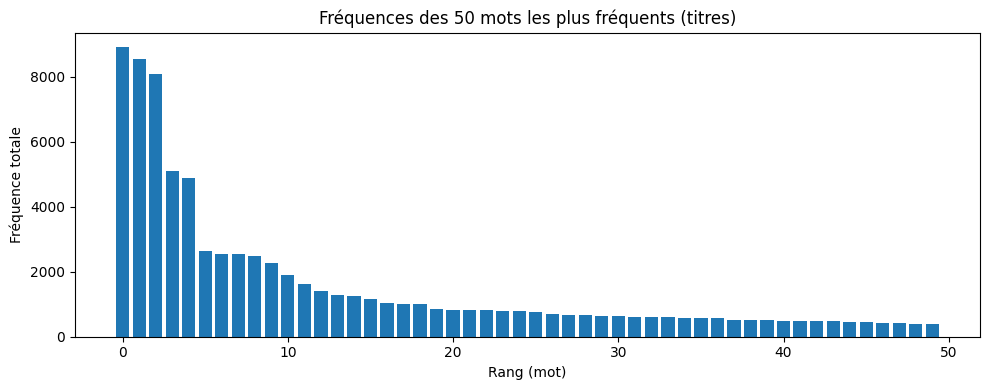

In [11]:
import matplotlib.pyplot as plt

top_n = 50
# fréquences triées du plus fréquent au moins fréquent
sorted_freqs = np.sort(word_counts)[::-1][:top_n]

plt.figure(figsize=(10, 4))
plt.bar(range(top_n), sorted_freqs)
plt.title(f"Fréquences des {top_n} mots les plus fréquents (titres)")
plt.xlabel("Rang (mot)")
plt.ylabel("Fréquence totale")
plt.tight_layout()
plt.show()